# Análisis y Predicciones de Compras Amazon

Análisis de datos de compras en Amazon: estadísticas descriptivas (promedio, mediana) por artículo y por paquete, predicciones simples de precio y frecuencia de compra.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
df = pd.read_csv('Amazon Products Clean.csv')
df.head()

,Producto,Fecha,Precio por Paquete,Paquetes,Unidades por Paquete,Precio por Compra,Unidades por Compra,Mes,Precio por Unidad
0,Stevia,15-may-26,84.50,1,1.00,84.50,1.00,Mayo,$84.50
1,Stevia,10-mar-26,91.00,1,1.00,91.00,1.00,Marzo,$91.00
2,Stevia,13-nov-25,97.00,1,1.00,97.00,1.00,Noviembre,$97.00
3,Corn Flakes,17-may-26,50.00,1,1.00,50.00,1.00,Mayo,$50.00
4,Corn Flakes,27-abr-26,46.80,1,1.00,46.80,1.00,Abril,$46.80


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 174 entries, 0 to 173
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Producto              174 non-null    object 
 1   Fecha                 174 non-null    object 
 2   Precio por Paquete    174 non-null    float64
 3   Paquetes              174 non-null    int64  
 4   Unidades por Paquete  174 non-null    float64
 5   Precio por Compra     174 non-null    float64
 6   Unidades por Compra   174 non-null    float64
 7   Mes                   174 non-null    object 
 8   Precio por Unidad     174 non-null    object 
dtypes: float64(4), int64(1), object(4)
memory usage: 12.4+ KB


,Precio por Paquete,Paquetes,Unidades por Paquete,Precio por Compra,Unidades por Compra
count,174.00,174.00,174.00,174.00,174.00
mean,69.27,1.48,2.56,354.41,3.80
std,86.96,1.05,4.82,1233.89,11.51
min,7.50,1.00,0.40,8.24,0.40
25%,19.92,1.00,1.00,35.00,1.00
50%,48.25,1.00,1.00,62.50,1.00
75%,76.00,2.00,1.00,157.50,3.00
max,785.00,8.00,48.00,13104.00,144.00


In [4]:
# Convertir "Precio por Unidad" de "$XX.XX" a float
df['Precio por Unidad'] = df['Precio por Unidad'].str.replace('$', '', regex=False).astype(float)

# Convertir "Fecha" a datetime con mapeo de meses en español
meses_map = {
    'ene': 'Jan', 'feb': 'Feb', 'mar': 'Mar', 'abr': 'Apr',
    'may': 'May', 'jun': 'Jun', 'jul': 'Jul', 'ago': 'Aug',
    'sep': 'Sep', 'oct': 'Oct', 'nov': 'Nov', 'dic': 'Dec'
}

def parse_fecha(fecha_str):
    for es, en in meses_map.items():
        fecha_str = fecha_str.replace(f'-{es}-', f'-{en}-')
    return pd.to_datetime(fecha_str, format='%d-%b-%y')

df['Fecha'] = df['Fecha'].apply(parse_fecha)

# Costo real de la compra = Precio por Paquete * Paquetes
# (La columna "Precio por Compra" del CSV multiplica también por Unidades por Paquete, lo cual infla el gasto)
df['Costo_Real'] = df['Precio por Paquete'] * df['Paquetes']

print("Tipos de datos después de limpieza:")
print(df.dtypes)
print(f"\nRango de fechas: {df['Fecha'].min().strftime('%d/%m/%Y')} a {df['Fecha'].max().strftime('%d/%m/%Y')}")
print(f"Rango de Precio por Unidad: ${df['Precio por Unidad'].min():.2f} a ${df['Precio por Unidad'].max():.2f}")
print(f"Rango de Costo Real: ${df['Costo_Real'].min():.2f} a ${df['Costo_Real'].max():.2f}")

Tipos de datos después de limpieza:
Producto                        object
Fecha                   datetime64[ns]
Precio por Paquete             float64
Paquetes                         int64
Unidades por Paquete           float64
Precio por Compra              float64
Unidades por Compra            float64
Mes                             object
Precio por Unidad              float64
Costo_Real                     float64
dtype: object

Rango de fechas: 30/10/2025 a 17/05/2026
Rango de Precio por Unidad: $1.90 a $560.71
Rango de Costo Real: $8.24 a $785.00


## Estadísticas por Producto (Artículo)

In [5]:
stats_producto = df.groupby('Producto').agg(
    Compras=('Producto', 'count'),
    Precio_Paquete_Promedio=('Precio por Paquete', 'mean'),
    Precio_Paquete_Mediana=('Precio por Paquete', 'median'),
    Precio_Unidad_Promedio=('Precio por Unidad', 'mean'),
    Precio_Unidad_Mediana=('Precio por Unidad', 'median'),
    Costo_Real_Promedio=('Costo_Real', 'mean'),
    Costo_Real_Mediana=('Costo_Real', 'median'),
).round(2)

# Moda por producto (precio más frecuente)
moda_unidad = df.groupby('Producto')['Precio por Unidad'].agg(
    lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
)
moda_paquete = df.groupby('Producto')['Precio por Paquete'].agg(
    lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
)

stats_producto['Precio_Unidad_Moda'] = moda_unidad.round(2)
stats_producto['Precio_Paquete_Moda'] = moda_paquete.round(2)

print("--- Estadísticas por Producto (incluye promedio, mediana y moda) ---\n")
stats_producto.sort_values('Compras', ascending=False)

--- Estadísticas por Producto (incluye promedio, mediana y moda) ---



,Compras,Precio_Paquete_Promedio,Precio_Paquete_Mediana,Precio_Unidad_Promedio,Precio_Unidad_Mediana,Costo_Real_Promedio,Costo_Real_Mediana,Precio_Unidad_Moda,Precio_Paquete_Moda
Producto,,,,,,,,,
Pure Tomate,17,8.59,8.75,8.59,8.75,21.75,17.50,8.75,8.75
Frijol Bolsa,12,16.00,16.74,16.00,16.74,35.54,26.97,18.60,18.60
Cheerios,7,56.24,54.00,56.24,54.00,72.43,59.20,54.00,54.00
Barilla Tornillo,6,19.50,19.50,19.50,19.50,26.09,19.75,19.00,19.00
Corn Flakes,6,49.09,48.40,49.09,48.40,65.05,56.00,40.00,40.00
...,...,...,...,...,...,...,...,...,...
Proteina,1,785.00,785.00,560.71,560.71,785.00,785.00,560.71,785.00
Saba,1,91.00,91.00,1.90,1.90,273.00,273.00,1.90,91.00
Sico,1,67.91,67.91,22.64,22.64,67.91,67.91,22.64,67.91


In [6]:
stats_mes = df.groupby('Mes').agg(
    Total_Compras=('Mes', 'count'),
    Gasto_Total=('Costo_Real', 'sum'),
    Gasto_Promedio=('Costo_Real', 'mean'),
    Gasto_Mediana=('Costo_Real', 'median'),
).round(2)

orden_meses = ['Octubre', 'Noviembre', 'Diciembre', 'Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo']
stats_mes = stats_mes.reindex([m for m in orden_meses if m in stats_mes.index])
stats_mes

,Total_Compras,Gasto_Total,Gasto_Promedio,Gasto_Mediana
Mes,,,,
Octubre,1,43.00,43.00,43.00
Noviembre,52,6676.61,128.40,84.43
Diciembre,12,855.48,71.29,51.00
Enero,13,1065.44,81.96,44.40
Febrero,31,2549.12,82.23,55.00
Marzo,30,1479.59,49.32,42.50
Abril,25,1542.10,61.68,50.00
Mayo,10,610.84,61.08,48.72


## Predicción de Precio Siguiente

Promedio ponderado: 40% último precio + 30% penúltimo precio + 30% promedio histórico.

In [7]:
# Todos los meses del período (octubre se fusiona con noviembre)
todos_los_meses = ['Noviembre', 'Diciembre', 'Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo']
total_meses = len(todos_los_meses)

predicciones = []
for producto in df['Producto'].unique():
    datos_prod = df[df['Producto'] == producto].sort_values('Fecha')
    precio_promedio = datos_prod['Precio por Paquete'].mean()
    precio_mediana = datos_prod['Precio por Paquete'].median()
    precio_unidad_promedio = datos_prod['Precio por Unidad'].mean()
    # Mediana de piezas por paquete, ponderada por número de paquetes comprados
    unidades_expanded = datos_prod['Unidades por Paquete'].repeat(datos_prod['Paquetes'].values)
    unidades_mediana = unidades_expanded.median()
    costo_estandar = unidades_mediana * precio_unidad_promedio
    ultimo_precio = datos_prod['Precio por Paquete'].iloc[-1]

    if len(datos_prod) >= 2:
        penultimo_precio = datos_prod['Precio por Paquete'].iloc[-2]
        estimacion = ultimo_precio * 0.4 + penultimo_precio * 0.3 + precio_promedio * 0.3
    else:
        penultimo_precio = np.nan
        estimacion = ultimo_precio

    # Compras y piezas por mes (incluir meses con 0)
    datos_tmp = datos_prod.copy()
    datos_tmp['Mes_Ajustado'] = datos_tmp['Mes'].replace('Octubre', 'Noviembre')

    compras_por_mes = datos_tmp.groupby('Mes_Ajustado').size().reindex(todos_los_meses, fill_value=0)
    piezas_por_mes = datos_tmp.groupby('Mes_Ajustado')['Unidades por Compra'].sum().reindex(todos_los_meses, fill_value=0)

    predicciones.append({
        'Producto': producto,
        'Precio_Promedio': round(precio_promedio, 2),
        'Precio_Mediana': round(precio_mediana, 2),
        'Precio_Unidad_Promedio': round(precio_unidad_promedio, 2),
        'Unidades_Mediana': round(unidades_mediana, 2),
        'Costo_Estandar': round(costo_estandar, 2),
        'Penultimo_Precio': round(penultimo_precio, 2) if pd.notna(penultimo_precio) else np.nan,
        'Ultimo_Precio': round(ultimo_precio, 2),
        'Estimacion_Siguiente': round(estimacion, 2),
        'Num_Compras': len(datos_prod),
        'Compras_Promedio_Mes': round(compras_por_mes.mean(), 2),
        'Compras_Mediana_Mes': round(compras_por_mes.median(), 2),
        'Piezas_Promedio_Mes': round(piezas_por_mes.mean(), 2),
        'Piezas_Mediana_Mes': round(piezas_por_mes.median(), 2),
    })

df_predicciones = pd.DataFrame(predicciones).sort_values('Num_Compras', ascending=False)
df_predicciones

,Producto,Precio_Promedio,Precio_Mediana,Precio_Unidad_Promedio,Unidades_Mediana,Costo_Estandar,Penultimo_Precio,Ultimo_Precio,Estimacion_Siguiente,Num_Compras,Compras_Promedio_Mes,Compras_Mediana_Mes,Piezas_Promedio_Mes,Piezas_Mediana_Mes
2,Pure Tomate,8.59,8.75,8.59,1.00,8.59,7.50,7.50,7.83,17,2.43,3.00,6.14,6.00
4,Frijol Bolsa,16.01,16.74,16.01,1.00,16.01,15.81,15.81,15.87,12,1.71,2.00,4.14,4.00
3,Cheerios,56.24,54.00,56.24,1.00,56.24,54.00,54.00,54.67,7,1.00,1.00,1.29,1.00
1,Corn Flakes,49.09,48.40,49.09,1.00,49.09,46.80,50.00,48.77,6,0.86,1.00,1.14,1.00
12,Barilla Tornillo,19.50,19.50,19.50,1.00,19.50,19.00,20.02,19.56,6,0.86,1.00,1.14,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,Proteina,785.00,785.00,560.71,1.40,784.99,NaN,785.00,785.00,1,0.14,0.00,0.20,0.00
57,Saba,91.00,91.00,1.90,48.00,91.20,NaN,91.00,91.00,1,0.14,0.00,20.57,0.00
58,Miel de Abeja,90.00,90.00,180.00,0.50,90.00,NaN,90.00,90.00,1,0.14,0.00,0.07,0.00
59,Mayonesa,73.00,73.00,100.69,0.72,73.00,NaN,73.00,73.00,1,0.14,0.00,0.10,0.00


In [13]:
df_predicciones.to_csv('predicciones.csv', index=False)

In [24]:
predicciones = pd.read_csv('predicciones.csv')
predicciones[predicciones['Unidades_Mediana'] > 1]

,Producto,Precio_Promedio,Precio_Mediana,Precio_Unidad_Promedio,Unidades_Mediana,Costo_Estandar,Penultimo_Precio,Ultimo_Precio,Estimacion_Siguiente,Num_Compras,Compras_Promedio_Mes,Compras_Mediana_Mes,Piezas_Promedio_Mes,Piezas_Mediana_Mes
6,Papel Higienico,83.88,81.00,10.60,6.00,63.58,81.00,29.00,61.06,6,0.86,1.00,11.71,6.00
7,Carlos V,65.60,50.00,14.25,14.00,199.53,50.00,50.00,54.68,5,0.71,0.00,7.57,0.00
9,Chokis,53.46,52.00,7.64,7.00,53.47,52.50,60.40,55.95,5,0.71,1.00,6.00,7.00
10,Axion,53.50,48.70,43.86,1.40,61.40,68.00,37.50,51.45,5,0.71,1.00,1.09,1.40
15,Jabon Neutro,52.50,60.92,15.66,4.00,62.63,74.67,13.50,43.55,4,0.57,1.00,2.57,2.00
16,Leche,335.50,327.00,27.96,12.00,335.49,336.00,399.00,361.05,4,0.57,0.00,6.86,0.00
22,Tampones,41.67,41.00,5.21,8.00,41.71,41.00,41.00,41.20,3,0.43,0.00,3.43,0.00
52,Galletas Gaveti,199.00,199.00,11.06,18.00,199.08,NaN,199.00,199.00,1,0.14,0.00,2.57,0.00
53,Sico,67.91,67.91,22.64,3.00,67.92,NaN,67.91,67.91,1,0.14,0.00,0.43,0.00
54,Gilette Cuchillas,127.50,127.50,63.75,2.00,127.50,NaN,127.50,127.50,1,0.14,0.00,0.29,0.00


In [9]:
frecuencia = []
for producto in df['Producto'].unique():
    datos_prod = df[df['Producto'] == producto].sort_values('Fecha')
    if len(datos_prod) >= 2:
        dias_entre_compras = datos_prod['Fecha'].diff().dt.days.dropna()
        frecuencia.append({
            'Producto': producto,
            'Dias_Promedio_Entre_Compras': round(dias_entre_compras.mean(), 1),
            'Dias_Mediana_Entre_Compras': round(dias_entre_compras.median(), 1),
            'Ultima_Compra': datos_prod['Fecha'].max().strftime('%Y-%m-%d'),
            'Num_Compras': len(datos_prod)
        })

df_frecuencia = pd.DataFrame(frecuencia).sort_values('Num_Compras', ascending=False)
df_frecuencia

,Producto,Dias_Promedio_Entre_Compras,Dias_Mediana_Entre_Compras,Ultima_Compra,Num_Compras
2,Pure Tomate,12.30,12.00,2026-05-17,17
4,Frijol Bolsa,17.30,13.00,2026-05-10,12
3,Cheerios,30.80,35.00,2026-05-17,7
1,Corn Flakes,37.00,35.00,2026-05-17,6
12,Barilla Tornillo,31.60,30.00,2026-04-08,6
31,Papel Higienico,37.00,30.00,2026-05-17,6
19,Papel Humedo,26.20,25.00,2026-03-12,6
32,Chokis,38.50,36.50,2026-04-17,5
7,Toallas Cocina,43.50,41.00,2026-05-06,5
5,Carlos V,20.80,17.00,2026-04-27,5


## Visualizaciones

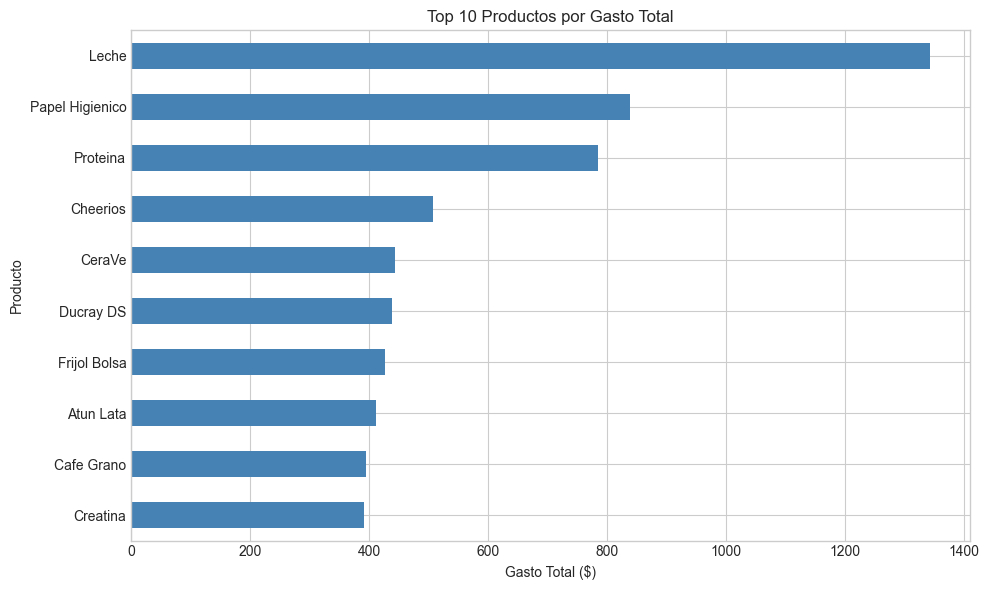

In [10]:
# Top 10 productos por gasto total real
gasto_por_producto = df.groupby('Producto')['Costo_Real'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots()
gasto_por_producto.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Gasto Total ($)')
ax.set_title('Top 10 Productos por Gasto Total')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

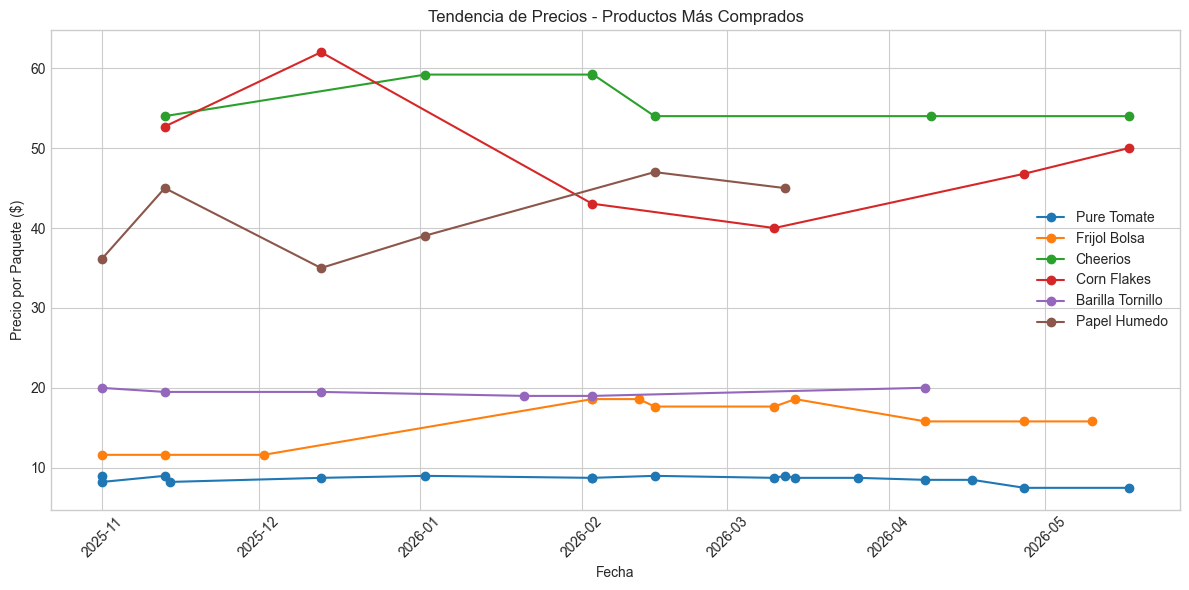

In [11]:
# Tendencia de precios para los 5 productos más comprados
top_productos = df['Producto'].value_counts().head(6).index.tolist()

fig, ax = plt.subplots(figsize=(12, 6))
for producto in top_productos:
    datos = df[df['Producto'] == producto].sort_values('Fecha')
    ax.plot(datos['Fecha'], datos['Precio por Unidad'], marker='o', label=producto)

ax.set_xlabel('Fecha')
ax.set_ylabel('Precio por Paquete ($)')
ax.set_title('Tendencia de Precios - Productos Más Comprados')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Resumen General

In [12]:
print("=" * 50)
print("RESUMEN DE ANÁLISIS")
print("=" * 50)
print(f"\nTotal de productos únicos: {df['Producto'].nunique()}")
print(f"Total de compras registradas: {len(df)}")
print(f"Período: {df['Fecha'].min().strftime('%d/%m/%Y')} - {df['Fecha'].max().strftime('%d/%m/%Y')}")
print(f"Gasto total: ${df['Costo_Real'].sum():,.2f}")
print(f"Gasto promedio por compra: ${df['Costo_Real'].mean():,.2f}")
print(f"Gasto mediana por compra: ${df['Costo_Real'].median():,.2f}")
print(f"\nProducto más comprado: {df['Producto'].value_counts().index[0]} ({df['Producto'].value_counts().iloc[0]} veces)")
print(f"Mes con más compras: {stats_mes['Total_Compras'].idxmax()} ({stats_mes['Total_Compras'].max():.0f} compras)")

RESUMEN DE ANÁLISIS

Total de productos únicos: 61
Total de compras registradas: 174
Período: 30/10/2025 - 17/05/2026
Gasto total: $14,822.18
Gasto promedio por compra: $85.18
Gasto mediana por compra: $54.00

Producto más comprado: Pure Tomate (17 veces)
Mes con más compras: Noviembre (52 compras)
